# Q1: Temperature Statistics Analysis

**Problem Statement:**
Temperatures (in °C) measured at noon for 11 consecutive days are:
31, 29, 27, 34, 32, 28, 33, 29, 35, 26, 30.

**Tasks:**
- (i) Compute the mean, median, variance, range, Q1, Q3 for this group.
- (ii) Identify whether the data is left/right skewed.
- (iii) Use the IQR method to identify the outliers in the data set.


In [7]:
pip install numpy pandas matplotlib seaborn scikit-learn scipy --quiet


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style for better plots
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')
    except:
        plt.style.use('default')
sns.set_palette("husl")


In [9]:
# Given temperature data
temperatures = [31, 29, 27, 34, 32, 28, 33, 29, 35, 26, 30]

# Convert to numpy array for easier calculations
temp_array = np.array(temperatures)

print("Temperature Data:", temperatures)
print(f"Number of observations: {len(temperatures)}")


Temperature Data: [31, 29, 27, 34, 32, 28, 33, 29, 35, 26, 30]
Number of observations: 11


## (i) Compute Mean, Median, Variance, Range, Q1, Q3


In [10]:
# Calculate statistics
mean_temp = np.mean(temp_array)
median_temp = np.median(temp_array)
variance_temp = np.var(temp_array, ddof=0)  # Population variance
range_temp = np.max(temp_array) - np.min(temp_array)
q1 = np.percentile(temp_array, 25)
q3 = np.percentile(temp_array, 75)

# Display results
print("=" * 50)
print("STATISTICAL MEASURES")
print("=" * 50)
print(f"Mean:     {mean_temp:.2f}°C")
print(f"Median:   {median_temp:.2f}°C")
print(f"Variance: {variance_temp:.2f}")
print(f"Range:    {range_temp:.2f}°C")
print(f"Q1 (25th percentile): {q1:.2f}°C")
print(f"Q3 (75th percentile): {q3:.2f}°C")
print("=" * 50)


STATISTICAL MEASURES
Mean:     30.36°C
Median:   30.00°C
Variance: 7.69
Range:    9.00°C
Q1 (25th percentile): 28.50°C
Q3 (75th percentile): 32.50°C


## (ii) Identify Skewness (Left/Right Skewed)


SKEWNESS ANALYSIS
Skewness coefficient: 0.1333
Skewness type: Right Skewed (Positively Skewed)
Interpretation: The tail extends to the right, mean > median

Mean: 30.36°C
Median: 30.00°C
Difference: 0.36°C


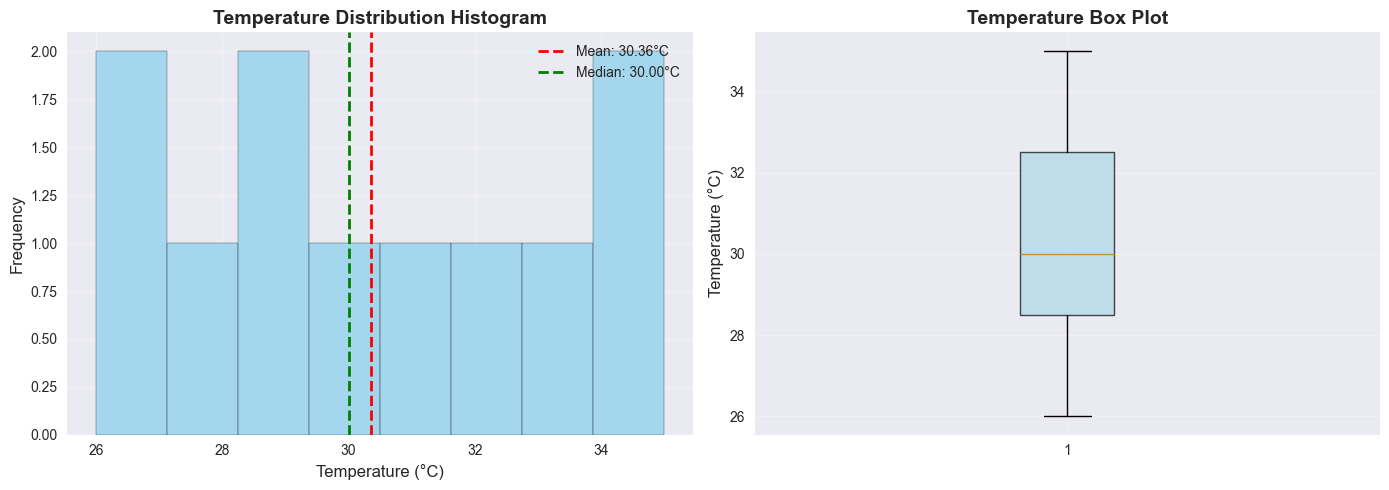

In [11]:
# Calculate skewness
skewness = stats.skew(temp_array)

# Determine skewness direction
if skewness > 0:
    skew_direction = "Right Skewed (Positively Skewed)"
    interpretation = "The tail extends to the right, mean > median"
elif skewness < 0:
    skew_direction = "Left Skewed (Negatively Skewed)"
    interpretation = "The tail extends to the left, mean < median"
else:
    skew_direction = "Symmetric (No Skew)"
    interpretation = "The distribution is approximately symmetric"

print("=" * 50)
print("SKEWNESS ANALYSIS")
print("=" * 50)
print(f"Skewness coefficient: {skewness:.4f}")
print(f"Skewness type: {skew_direction}")
print(f"Interpretation: {interpretation}")
print(f"\nMean: {mean_temp:.2f}°C")
print(f"Median: {median_temp:.2f}°C")
print(f"Difference: {mean_temp - median_temp:.2f}°C")
print("=" * 50)

# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(temp_array, bins=8, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(mean_temp, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_temp:.2f}°C')
axes[0].axvline(median_temp, color='green', linestyle='--', linewidth=2, label=f'Median: {median_temp:.2f}°C')
axes[0].set_xlabel('Temperature (°C)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Temperature Distribution Histogram', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
box_plot = axes[1].boxplot(temp_array, vert=True, patch_artist=True, 
                          boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1].set_ylabel('Temperature (°C)', fontsize=12)
axes[1].set_title('Temperature Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## (iii) Identify Outliers using IQR Method


OUTLIER DETECTION USING IQR METHOD
Q1 (25th percentile): 28.50°C
Q3 (75th percentile): 32.50°C
IQR (Q3 - Q1): 4.00°C

Lower Bound (Q1 - 1.5 × IQR): 22.50°C
Upper Bound (Q3 + 1.5 × IQR): 38.50°C

Outliers: None
Number of outliers: 0


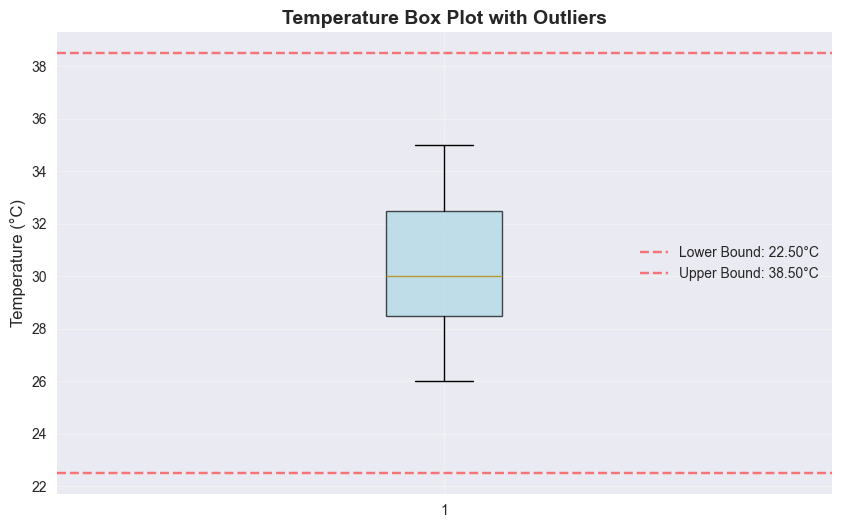


SUMMARY TABLE:
Statistic    Value
     Mean  30.36°C
   Median  30.00°C
 Variance     7.69
    Range   9.00°C
       Q1  28.50°C
       Q3  32.50°C
      IQR   4.00°C
 Skewness   0.1333
 Outliers 0 (None)


In [12]:
# Calculate IQR (Interquartile Range)
iqr = q3 - q1

# Define outlier boundaries
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify outliers
outliers = temp_array[(temp_array < lower_bound) | (temp_array > upper_bound)]

print("=" * 50)
print("OUTLIER DETECTION USING IQR METHOD")
print("=" * 50)
print(f"Q1 (25th percentile): {q1:.2f}°C")
print(f"Q3 (75th percentile): {q3:.2f}°C")
print(f"IQR (Q3 - Q1): {iqr:.2f}°C")
print(f"\nLower Bound (Q1 - 1.5 × IQR): {lower_bound:.2f}°C")
print(f"Upper Bound (Q3 + 1.5 × IQR): {upper_bound:.2f}°C")
print(f"\nOutliers: {outliers.tolist() if len(outliers) > 0 else 'None'}")
print(f"Number of outliers: {len(outliers)}")
print("=" * 50)

# Visualize outliers
fig, ax = plt.subplots(figsize=(10, 6))
box_plot = ax.boxplot(temp_array, vert=True, patch_artist=True, 
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     showfliers=True)

# Highlight outliers if any
if len(outliers) > 0:
    for outlier in outliers:
        ax.plot(1, outlier, 'ro', markersize=10, label='Outlier' if outlier == outliers[0] else '')
    ax.legend()

ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title('Temperature Box Plot with Outliers', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(lower_bound, color='red', linestyle='--', alpha=0.5, label=f'Lower Bound: {lower_bound:.2f}°C')
ax.axhline(upper_bound, color='red', linestyle='--', alpha=0.5, label=f'Upper Bound: {upper_bound:.2f}°C')
ax.legend()
plt.show()

# Summary table
summary_df = pd.DataFrame({
    'Statistic': ['Mean', 'Median', 'Variance', 'Range', 'Q1', 'Q3', 'IQR', 'Skewness', 'Outliers'],
    'Value': [f'{mean_temp:.2f}°C', f'{median_temp:.2f}°C', f'{variance_temp:.2f}', 
              f'{range_temp:.2f}°C', f'{q1:.2f}°C', f'{q3:.2f}°C', f'{iqr:.2f}°C',
              f'{skewness:.4f}', f'{len(outliers)} ({outliers.tolist() if len(outliers) > 0 else "None"})']
})
print("\nSUMMARY TABLE:")
print(summary_df.to_string(index=False))
